In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./kaggle/input/test.csv
./kaggle/input/train.csv
./kaggle/input/gender_submission.csv


# 1. EDA

In [4]:
train_data = pd.read_csv("./kaggle/input/train.csv")

In [13]:
train_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Most missing data
- Age: 20%
- Cabin: 78%: Probably gonna throw it out though
- Embarked: 0.22%

In [12]:
# Check missing ratio for each column
train_data.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

<Axes: xlabel='Survived'>

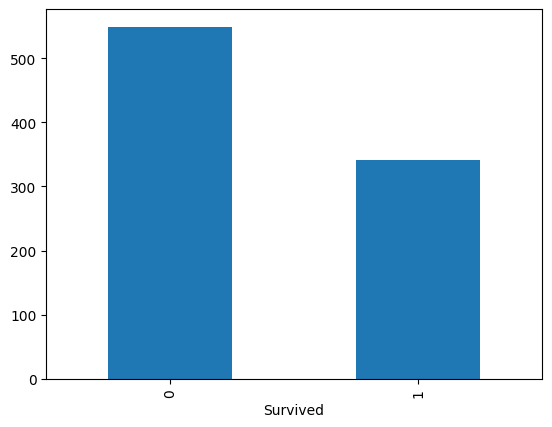

In [8]:
# Bar plot survived vs not survived
train_data['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass'>

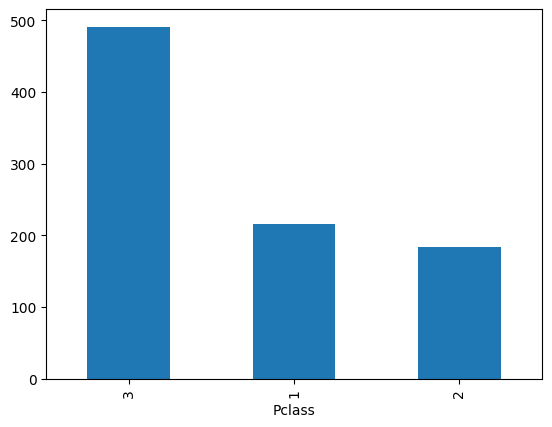

In [9]:
train_data['Pclass'].value_counts().plot(kind='bar')

<Axes: xlabel='Sex'>

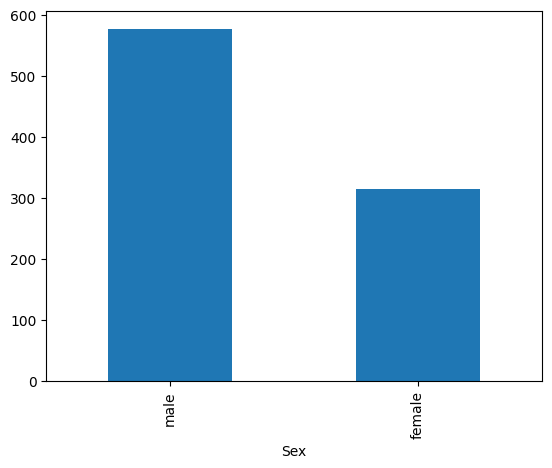

In [10]:
train_data["Sex"].value_counts().plot(kind='bar')

<Axes: >

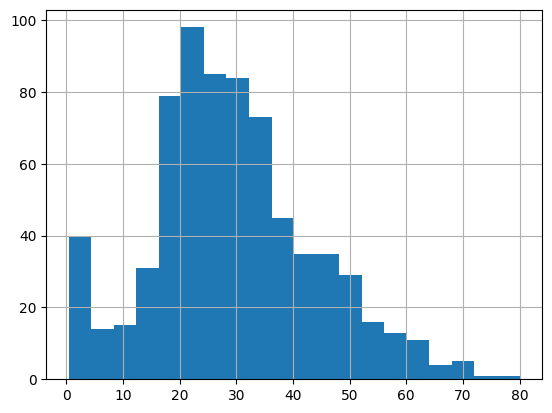

In [11]:
train_data["Age"].hist(bins=20)

<Axes: xlabel='SibSp'>

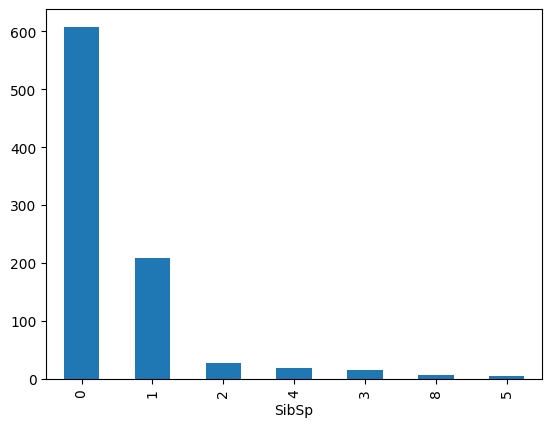

In [14]:
train_data["SibSp"].value_counts().plot(kind='bar')

<Axes: xlabel='Parch'>

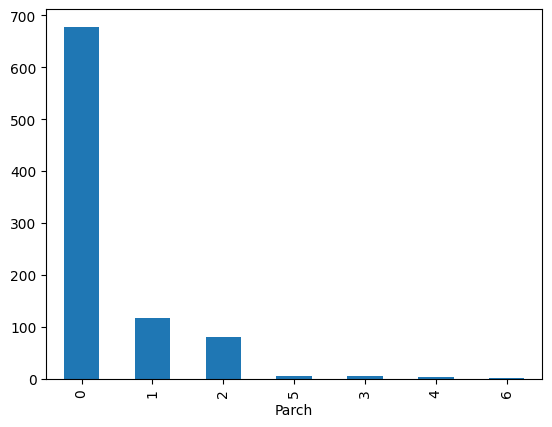

In [15]:
train_data["Parch"].value_counts().plot(kind='bar')

Some tickets are shared - which might very likely to be useful!

In [16]:
train_data["Ticket"].nunique() / len(train_data)  # High cardinality, probably drop

0.7643097643097643

<Axes: >

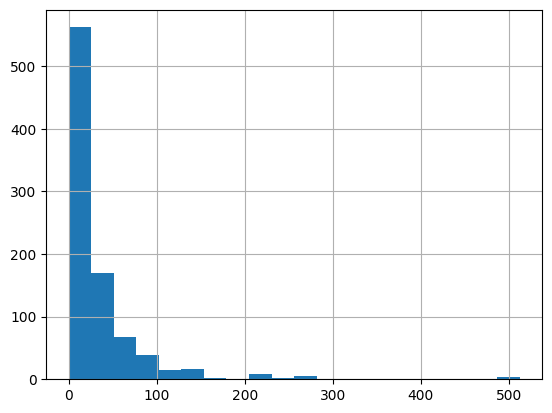

In [17]:
train_data["Fare"].hist(bins=20)

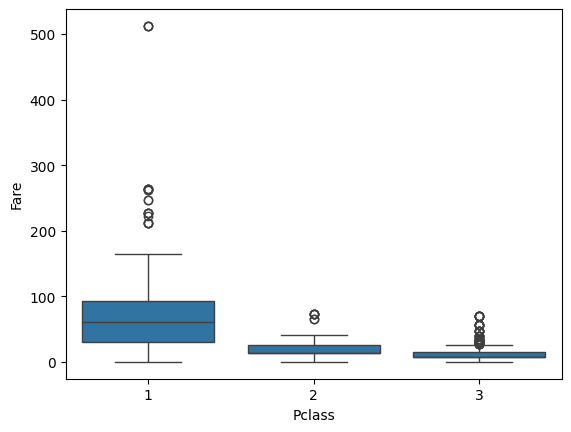

In [18]:
# Relation between pclass and fare
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="Pclass", y="Fare", data=train_data)
plt.show()

# 2. Data Cleaning

## 2.1 Fill Missing Data

In [37]:
train_data = pd.read_csv("./kaggle/input/train.csv")

Fill age/embared by median

In [39]:
train_data_cl = train_data.copy()

In [40]:
# Fill missing age/embared by median
train_data_cl["Age"] = train_data_cl["Age"].fillna(train_data_cl["Age"].median())
train_data_cl["Embarked"] = train_data_cl["Embarked"].fillna(train_data_cl["Embarked"].mode()[0])

Remove cabin because too many nans

In [41]:
train_data_cl = train_data_cl.drop(columns=["Cabin"])

## 2.2 One-Hot Encoding

Categorical vars:

- Pclass
- Sex
- Ticket - too many uniques
- Embarked

In [45]:
# Convert Pclass to one-hot encoding
pclass_dummies = pd.get_dummies(train_data_cl["Pclass"], prefix="Pclass", drop_first=True, dtype=int)

display(pclass_dummies.head())

,Pclass_2,Pclass_3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


In [46]:
# Convert Sex to one-hot encoding
sex_dummies = pd.get_dummies(train_data_cl["Sex"], prefix="Sex", drop_first=True, dtype=int)

display(sex_dummies.head())

,Sex_male
0,1
1,0
2,0
3,0
4,1


In [47]:
# Convert Embarked to one-hot encoding
embarked_dummies = pd.get_dummies(train_data_cl["Embarked"], prefix="Embarked", drop_first=True, dtype=int)

display(embarked_dummies.head())

,Embarked_Q,Embarked_S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


Concat all the dummies and remove the original

In [48]:
train_data_cl_2 = train_data_cl.drop(columns=["Pclass", "Sex", "Embarked", "Ticket"])
train_data_cl_2 = pd.concat([train_data_cl_2, pclass_dummies, sex_dummies, embarked_dummies], axis=1)

Remove unused columns
- PassengerId
- Name

In [51]:
train_data_cl_2 = train_data_cl_2.drop(columns=["PassengerId", "Name"])

In [52]:
train_data_cl_2.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,0,1,1,0,1
1,1,38.0,1,0,71.2833,0,0,0,0,0
2,1,26.0,0,0,7.9250,0,1,0,0,1
3,1,35.0,1,0,53.1000,0,0,0,0,1
4,0,35.0,0,0,8.0500,0,1,1,0,1


In [53]:
np.isfinite(train_data_cl_2).all()

Survived      True
Age           True
SibSp         True
Parch         True
Fare          True
Pclass_2      True
Pclass_3      True
Sex_male      True
Embarked_Q    True
Embarked_S    True
dtype: bool

# 3. Evaluation Utilities

## Train-Test Split & X/Y Extract

In [59]:
# Train test split
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(train_data_cl_2, test_size=0.2, random_state=42)

def generate_feature_target(data):
    X = data.drop(columns=["Survived"])
    y = data["Survived"]
    return X, y

X_train, y_train = generate_feature_target(data_train)

X_val, y_val = generate_feature_target(data_val)


In [93]:
X_full, y_full = generate_feature_target(train_data_cl_2)

## Evaluation Setup

In [64]:
def evaluate_accuracy(model, X_train, y_train, X_val, y_val, fit_model=True):
    from sklearn.metrics import accuracy_score

    if fit_model:
        model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    return train_accuracy, val_accuracy

# 4. Modeling

## 4.1 SVC

In [65]:
## Support Vector Classifier

from sklearn.svm import SVC

svc_model = SVC(random_state=42)

train_accuracy_svc, val_accuracy_svc = evaluate_accuracy(svc_model, X_train, y_train, X_val, y_val)

Train Accuracy: 0.6685
Validation Accuracy: 0.6536


## 4.2 SVC w/ Cross-Validation

In [67]:
# Suuport Vector Classifier with Cross-Validation to choose hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    # 'kernel': ['linear', 'rbf', 'poly'],
    # 'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [68]:
train_accuracy_svc_cv, val_accuracy_svc_cv = evaluate_accuracy(grid_search.best_estimator_, X_train, y_train, X_val, y_val, fit_model=False)

Train Accuracy: 0.7275
Validation Accuracy: 0.7263


## 4.3 Random-Forest w/ Cross-Validation

In [97]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [98]:
train_accuracy_rf_cv, val_accuracy_rf_cv = evaluate_accuracy(grid_search_rf.best_estimator_, X_train, y_train, X_val, y_val, fit_model=False)

Train Accuracy: 0.8567
Validation Accuracy: 0.8156


## 4.* Determine Model & Refit Using Full Data

In [100]:
# Refit using full data

best_model = grid_search_rf.best_estimator_
best_model.fit(X_full, y_full)


,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 5. Test Predictions

## 5.1 Prepare Test Data

In [71]:
test_data = pd.read_csv("./kaggle/input/test.csv")

In [72]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [81]:
test_data_cl = test_data.copy()

test_data_cl["Age"] = test_data_cl["Age"].fillna(test_data_cl["Age"].median())
test_data_cl["Embarked"] = test_data_cl["Embarked"].fillna(test_data_cl["Embarked"].mode()[0])
test_data_cl["Fare"] = test_data_cl["Fare"].fillna(test_data_cl["Fare"].median())
test_data_cl = test_data_cl.drop(columns=["Cabin"])

# One hot encoding for test data
pclass_dummies_test = pd.get_dummies(test_data_cl["Pclass"], prefix="Pclass", drop_first=True, dtype=int)
sex_dummies_test = pd.get_dummies(test_data_cl["Sex"], prefix="Sex", drop_first=True, dtype=int)
embarked_dummies_test = pd.get_dummies(test_data_cl["Embarked"], prefix="Embarked", drop_first=True, dtype=int)
test_data_cl_2 = test_data_cl.drop(columns=["Pclass", "Sex", "Embarked", "Ticket"])
test_data_cl_2 = pd.concat([test_data_cl_2, pclass_dummies_test, sex_dummies_test, embarked_dummies_test], axis=1)
test_data_cl_2 = test_data_cl_2.drop(columns=["PassengerId", "Name"])

## 5.2 Predict w/ Best Model

In [102]:
Y_pred = best_model.predict(test_data_cl_2)

results = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": Y_pred
})

results.to_csv("submission.csv", index=False)